# CIFAR-10 Classification Pipeline
**PUC-Campinas · Engenharia de Software · IAAM · Avaliação Prática 2**

---

# Integrantes do grupo:

João Pedro Duarte Giatti - 24019083

Jean Yuki Kimura - 24008214

Eduarda Luiza Pinheiro Nepomuceno - 24002529

## 1. Importações

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
import  torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset
from collections import Counter

RANDOM_STATE = 2025
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# DEVICE
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__} | Torchvision: {torchvision.__version__}')

Device: cpu
PyTorch: 2.12.0+cpu | Torchvision: 0.27.0+cpu


## 2. Carregamento do Dataset

In [9]:
# transform mínimo para carregamento inicial (apenas tensor, sem normalização ainda)
raw_transform = transforms.ToTensor()

# carrega treino + teste do CIFAR-10
cifar_train_raw = CIFAR10(root='./data', train=True,  download=True, transform=raw_transform)
cifar_test_raw  = CIFAR10(root='./data', train=False, download=True, transform=raw_transform)

# Nomes das 10 classes
CLASS_NAMES = cifar_train_raw.classes
print('Classes:', CLASS_NAMES)
print(f'Treino (raw): {len(cifar_train_raw)} amostras')
print(f'Teste  (raw): {len(cifar_test_raw)}  amostras')

# Armazena estrutura indexável features + labels
dataset = cifar_train_raw + cifar_test_raw # (60 000 amostras)
print(f'dataset total : {len(dataset)} amostras')
print(f'Forma de uma amostra — imagem: {dataset[0][0].shape}, label: {dataset[0][1]}')

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Treino (raw): 50000 amostras
Teste  (raw): 10000  amostras
dataset total : 60000 amostras
Forma de uma amostra — imagem: torch.Size([3, 32, 32]), label: 6


## 3. Visualização Inicial

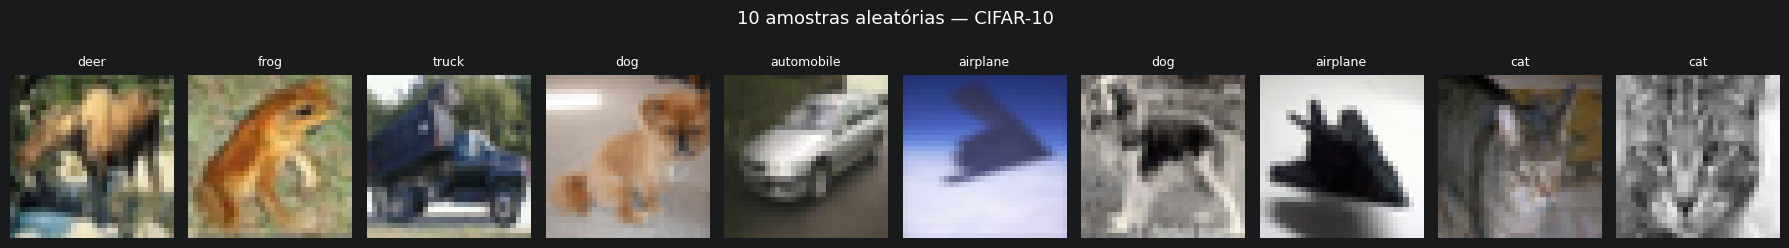

In [12]:
# 10 amostras aleatórias
rng = random.Random(RANDOM_STATE)
sample_indices = rng.sample(range(len(dataset)), 10)

fig, axes = plt.subplots(1, 10, figsize=(18, 2.5))
fig.suptitle('10 amostras aleatórias — CIFAR-10', fontsize=13, y=1.02)

for ax, idx in zip(axes, sample_indices):
    img_tensor, label = dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()   # CHW → HWC
    ax.imshow(img_np)
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# contagem por classe
all_labels = [dataset[i][1] for i in range(len(dataset))]
counts = Counter(all_labels)

print(f'{"Classe":<15} {"ID":>4} {"Total":>8}')
print('-' * 30)
for cid, cname in enumerate(CLASS_NAMES):
    print(f'{cname:<15} {cid:>4} {counts[cid]:>8}')
print('-' * 30)
print(f'{"TOTAL":<15} {"":>4} {sum(counts.values()):>8}')

Classe            ID    Total
------------------------------
airplane           0     6000
automobile         1     6000
bird               2     6000
cat                3     6000
deer               4     6000
dog                5     6000
frog               6     6000
horse              7     6000
ship               8     6000
truck              9     6000
------------------------------
TOTAL                   60000


In [14]:
# ── 3.3  Forma dos dados ─────────────────────────────────────────────────────
sample_img, sample_lbl = dataset[0]
print('Forma da imagem (C, H, W):', tuple(sample_img.shape))
print('Tipo do tensor           :', sample_img.dtype)
print('Valor mín / máx          :', sample_img.min().item(), '/', sample_img.max().item())
print('Total de classes         :', len(CLASS_NAMES))
print('Total de amostras no Dataset:', len(dataset))

Forma da imagem (C, H, W): (3, 32, 32)
Tipo do tensor           : torch.float32
Valor mín / máx          : 0.0 / 1.0
Total de classes         : 10
Total de amostras no Dataset: 60000


## 3. Pré-processamento e Data Augmentation

In [16]:
# Média e desvio padrão por canal do CIFAR-10 (valores padrão da literatura)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# Transform para TREINO — com augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Transform para VALIDAÇÃO e TESTE — sem augmentation, só normaliza
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

print('Transform treino:')
print(transform_train)
print('\nTransform validação/teste:')
print(transform_eval)

Transform treino:
Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)

Transform validação/teste:
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


## 4. Divisão dos Dados — Treino / Validação / Teste

In [24]:
from sklearn.model_selection import train_test_split

# Labels do dataset completo (60k amostras)
all_labels = [dataset[i][1] for i in range(len(dataset))]
indices = list(range(len(dataset)))

# Split estratificado: 70% treino, 30% restante
idx_train, idx_temp = train_test_split(
    indices,
    test_size=0.30,
    stratify=all_labels,
    random_state=RANDOM_STATE
)

# Split do restante: 50% validação, 50% teste (= 15% e 15% do total)
labels_temp = [all_labels[i] for i in idx_temp]
idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    stratify=labels_temp,
    random_state=RANDOM_STATE
)

print(f'Treino     : {len(idx_train):>6} amostras ({len(idx_train)/len(dataset)*100:.1f}%)')
print(f'Validação  : {len(idx_val):>6} amostras ({len(idx_val)/len(dataset)*100:.1f}%)')
print(f'Teste      : {len(idx_test):>6} amostras ({len(idx_test)/len(dataset)*100:.1f}%)')

Treino     :  42000 amostras (70.0%)
Validação  :   9000 amostras (15.0%)
Teste      :   9000 amostras (15.0%)


In [25]:
from torchvision.datasets import CIFAR10

# Datasets com transforms corretos aplicados
cifar_full_train = CIFAR10(root='./data', train=True,  download=False, transform=transform_train)
cifar_full_eval  = CIFAR10(root='./data', train=True,  download=False, transform=transform_eval)
cifar_test_ds    = CIFAR10(root='./data', train=False, download=False, transform=transform_eval)

# Subsets — treino com augmentation, val/teste sem
# Os 50k de train=True + 10k de train=False = 60k total
# idx_train/val/test foram gerados sobre o dataset completo (60k)
# Separamos os índices dentro do split corretamente
train_dataset = Subset(cifar_full_train, idx_train)
val_dataset   = Subset(cifar_full_eval,  idx_val)
test_dataset  = Subset(cifar_full_eval,  idx_test)

# DataLoaders
g = torch.Generator()
g.manual_seed(RANDOM_STATE)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  generator=g, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=0)

print('DataLoaders criados!')
print(f'Batches treino    : {len(train_loader)}')
print(f'Batches validação : {len(val_loader)}')
print(f'Batches teste     : {len(test_loader)}')

DataLoaders criados!
Batches treino    : 329
Batches validação : 71
Batches teste     : 71


In [26]:
# Tabela de amostras por classe em cada partição
print(f'{"Classe":<15} {"Treino":>8} {"Validação":>10} {"Teste":>8}')
print('-' * 45)

train_labels = [dataset[i][1] for i in idx_train]
val_labels   = [dataset[i][1] for i in idx_val]
test_labels  = [dataset[i][1] for i in idx_test]

c_train = Counter(train_labels)
c_val   = Counter(val_labels)
c_test  = Counter(test_labels)

for cid, cname in enumerate(CLASS_NAMES):
    print(f'{cname:<15} {c_train[cid]:>8} {c_val[cid]:>10} {c_test[cid]:>8}')

print('-' * 45)
print(f'{"TOTAL":<15} {len(idx_train):>8} {len(idx_val):>10} {len(idx_test):>8}')

Classe            Treino  Validação    Teste
---------------------------------------------
airplane            4200        900      900
automobile          4200        900      900
bird                4200        900      900
cat                 4200        900      900
deer                4200        900      900
dog                 4200        900      900
frog                4200        900      900
horse               4200        900      900
ship                4200        900      900
truck               4200        900      900
---------------------------------------------
TOTAL              42000       9000     9000
